## **Classwork: "Assembling the Transformer" — From Self-Attention to a Full Encoder Block**

**The Scenario**

In the last session you built a single-head self-attention layer. Your tech lead at "ContextAI" is impressed, but points out that a single attention head can only learn one type of relationship between tokens at a time — subject-verb agreement, say, but not coreference and word-order structure simultaneously. She asks you to extend your implementation into a complete **Transformer encoder block**: multi-head attention (so the model can attend to many relationship types in parallel), positional encoding (so the model knows token order), a position-wise feed-forward network (to add non-linearity after attention), and residual connections with layer normalisation (to keep gradients healthy and training stable). By the end you will have assembled, from scratch, the building block that powers BERT, RoBERTa, and every modern encoder.

## **Part 1:**

### **Question 1: Why Multi-Head Attention?**

In the previous notebook you implemented single-head attention, where one set of $W_Q, W_K, W_V$ matrices projects tokens into one query/key/value space. Multi-head attention runs $H$ independent attention heads in parallel and concatenates their outputs. What is the primary motivation for this?

A) Multiple heads reduce the total number of parameters compared to a single large attention layer.

B) Each head can learn to attend to different types of relationships (e.g. syntactic dependencies, coreference, positional proximity) simultaneously, because each head has its own independent projection matrices and therefore its own learned subspace.

C) Multiple heads allow the model to process different sentences in a batch at the same time.

D) Concatenating head outputs is required to make the output dimension match the input dimension for the residual connection.

B) Each head can learn to attend to different types of relationships simultaneously, because every head has its own projection matrices and therefore its own learned subspace.


### **Question 2: Positional Encoding**

Unlike RNNs, self-attention has no built-in notion of order — if you permute the tokens in the input sequence, the attention scores change but the model has no way to distinguish "cat sat" from "sat cat" without additional information. The original Transformer (Vaswani et al., 2017) addresses this by **adding** a positional encoding vector $PE_{pos}$ to each token embedding before it enters the first layer.

Which of the following correctly describes why the sinusoidal positional encoding is designed the way it is?

A) Sinusoids are used because they are always positive, preventing negative activations in the first layer.

B) Each position gets a unique vector of $\sin$ and $\cos$ values at different frequencies, so the model can learn to attend by relative position — the encoding of position $pos + k$ can be expressed as a linear function of the encoding of position $pos$, making relative distances learnable.

C) The sinusoidal encoding replaces the embedding layer entirely, so no learned token embeddings are needed.

D) Sinusoids are used because they guarantee the positional encoding has unit norm, preventing scale mismatch with the token embeddings.

B) The sinusoidal encoding gives each position a unique pattern of $\sin$ and $\cos$ values across multiple frequencies, and the different wavelengths make relative offsets easier to recover from the representations.


### **Question 3: Residual Connections and Layer Normalisation**

Each sub-layer in a Transformer block (attention and feed-forward) is wrapped with a residual connection and layer normalisation:
$$\text{output} = \text{LayerNorm}(x + \text{Sublayer}(x))$$

What are the two distinct problems that this "Add & Norm" pattern solves?

A) The residual connection speeds up matrix multiplication, and layer norm converts outputs into probabilities.

B) The residual connection provides a direct gradient path that mitigates vanishing gradients in deep networks, and layer norm stabilises the distribution of activations across features within each token so that training is not sensitive to the scale of earlier layers.

C) The residual connection ensures attention weights sum to 1, and layer norm ensures weight matrices stay orthogonal.

D) The residual connection doubles the model's effective depth, and layer norm is equivalent to dropout regularisation.

B) The residual connection provides a direct gradient path that mitigates vanishing gradients in deep networks, and layer norm stabilises the distribution of activations across features within each token so training is less sensitive to scale.


## **Part 2:**

### **Question 4: Dimension Accounting Through a Transformer Block**

A Transformer encoder is configured as follows:

| Hyperparameter | Value |
|---|---|
| $d_{\text{model}}$ (embedding dimension) | 512 |
| $H$ (number of attention heads) | 8 |
| $d_k = d_v = d_{\text{model}} / H$ | 64 |
| $d_{\text{ff}}$ (feed-forward inner dimension) | 2048 |
| Sequence length $T$ | 10 |

Answer the following, showing your working:

1. Each head has its own $W_Q^{(h)}, W_K^{(h)}, W_V^{(h)}$ matrices. What is the shape of each of these matrices?

2. After the 8 heads each produce an output of shape $(T, d_v)$, they are concatenated and projected by $W_O$ (shape $Hd_v \times d_{\text{model}}$). What is the shape of the final multi-head attention output?

3. The feed-forward sub-layer applies two linear transforms: $\text{FFN}(x) = \text{ReLU}(x W_1 + b_1) W_2 + b_2$, where $W_1 \in \mathbb{R}^{d_{\text{model}} \times d_{\text{ff}}}$ and $W_2 \in \mathbb{R}^{d_{\text{ff}} \times d_{\text{model}}}$. What is the shape of the tensor after $W_1$ is applied, and after $W_2$ is applied?

4. What is the shape of the tensor at the **output** of the full encoder block (after Add & Norm)? Does it match the input shape? Why is this important?

1. Each head has shape $(512, 64)$ for $W_Q^{(h)}$, $W_K^{(h)}$, and $W_V^{(h)}$.
2. The concatenated head output is $(10, 512)$, and after $W_O$ the final multi-head attention output is also $(10, 512)$.
3. After $W_1$ the tensor has shape $(10, 2048)$, and after $W_2$ it has shape $(10, 512)$.
4. The encoder block output has shape $(10, 512)$, which matches the input shape. This is important because it lets encoder blocks be stacked repeatedly and keeps the residual additions dimensionally valid.


## **Part 3: Coding Challenge — Building a Transformer Encoder Block**

You will assemble a complete Transformer encoder block from scratch in NumPy. Each component (positional encoding, multi-head attention, feed-forward, layer norm) is a separate function. You wire them together in the final `encoder_block` function.

**Fill in the lines marked `## FILL IN`.**

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Hyperparameters (deliberately small for manual inspection) ---
T       = 6       # sequence length
d_model = 16      # embedding dimension
H       = 2       # number of attention heads
d_k     = d_model // H   # = 8  (per-head key/query dim)
d_v     = d_model // H   # = 8  (per-head value dim)
d_ff    = 32      # feed-forward inner dimension

tokens  = ["the", "cat", "sat", "on", "the", "mat"]

# Simulated input token embeddings  (T x d_model)
X = np.random.randn(T, d_model)

print("Configuration:")
print(f"  T={T}, d_model={d_model}, H={H}, d_k={d_k}, d_v={d_v}, d_ff={d_ff}")
print(f"  Input X shape: {X.shape}")

Configuration:
  T=6, d_model=16, H=2, d_k=8, d_v=8, d_ff=32
  Input X shape: (6, 16)


Positional encoding shape: (6, 16)


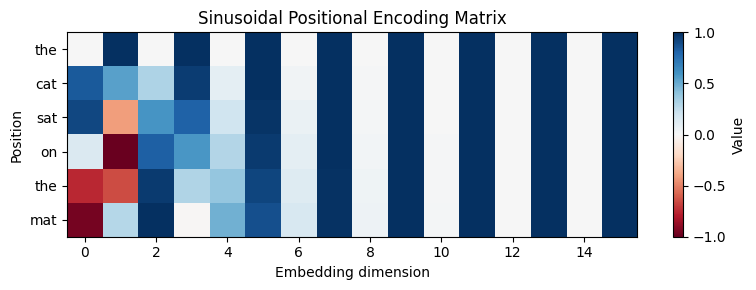

In [7]:
# ---------------------------------------------------------------
# Task A: Sinusoidal Positional Encoding
#
# PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
#
# where pos is the token position (0, 1, ..., T-1)
# and i  is the dimension index (0, 1, ..., d_model/2 - 1)
# ---------------------------------------------------------------

def positional_encoding(T, d_model):
    """
    Returns a (T, d_model) matrix of sinusoidal positional encodings.
    """
    PE = np.zeros((T, d_model))

    positions = np.arange(T).reshape(-1, 1)          # (T, 1)
    dims      = np.arange(0, d_model, 2)              # even indices: 0, 2, 4, ...

    ## FILL IN: compute the denominator term for each dimension
    ## denominator = 10000 ^ (dims / d_model)
    ## Hint: use np.power(10000, dims / d_model)
    denominator = np.power(10000, dims / d_model)

    ## FILL IN: fill even columns with sin, odd columns with cos
    PE[:, 0::2] = np.sin(positions / denominator)
    PE[:, 1::2] = np.cos(positions / denominator)

    return PE


PE = positional_encoding(T, d_model)
X_with_pos = X + PE   # add positional encoding to token embeddings

print(f"Positional encoding shape: {PE.shape}")

# Visualise the positional encoding matrix
plt.figure(figsize=(8, 3))
plt.imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Value')
plt.xlabel('Embedding dimension')
plt.ylabel('Position')
plt.yticks(range(T), tokens)
plt.title('Sinusoidal Positional Encoding Matrix')
plt.tight_layout()
plt.show()

Multi-head attention output shape: (6, 16)


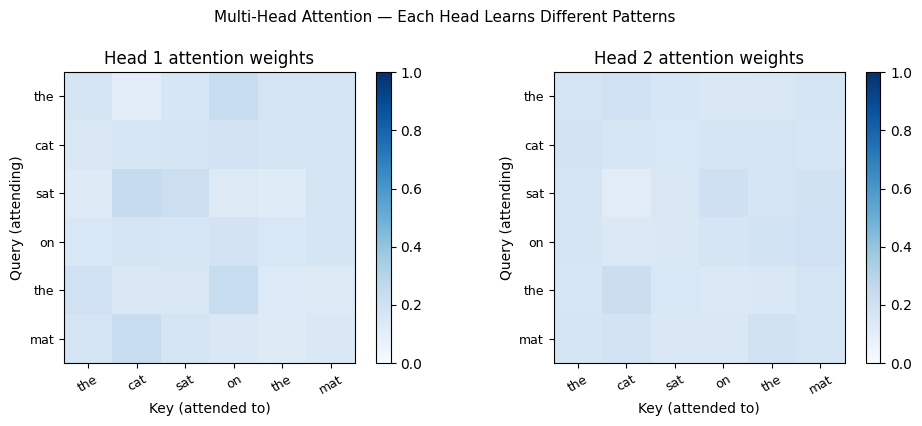

In [8]:
# ---------------------------------------------------------------
# Task B: Multi-Head Attention
#
# Each head h runs independent scaled dot-product attention
# using its own projection matrices W_Q[h], W_K[h], W_V[h].
# The head outputs are concatenated and projected by W_O.
# ---------------------------------------------------------------

def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def single_head_attention(X, W_Q, W_K, W_V):
    """Scaled dot-product attention (from the previous notebook)."""
    d_k    = W_Q.shape[1]
    Q      = X @ W_Q
    K      = X @ W_K
    V      = X @ W_V
    scores = (Q @ K.T) / np.sqrt(d_k)
    attn_w = softmax(scores)
    return attn_w @ V, attn_w


def multi_head_attention(X, W_Qs, W_Ks, W_Vs, W_O):
    """
    Multi-head attention.

    Args:
        X    : (T, d_model)
        W_Qs : list of H matrices, each (d_model, d_k)
        W_Ks : list of H matrices, each (d_model, d_k)
        W_Vs : list of H matrices, each (d_model, d_v)
        W_O  : (H * d_v, d_model)  — output projection

    Returns:
        output    : (T, d_model)
        all_heads : list of H attention weight matrices, each (T, T)
    """
    head_outputs = []
    all_heads    = []

    for h in range(len(W_Qs)):
        ## FILL IN: run single_head_attention for head h
        ## store the head output in head_outputs and weights in all_heads
        head_out, attn_w = single_head_attention(X, W_Qs[h], W_Ks[h], W_Vs[h])
        head_outputs.append(head_out)
        all_heads.append(attn_w)

    ## FILL IN: concatenate all head outputs along the feature axis
    ## concat shape: (T, H * d_v)
    ## then project through W_O to get shape (T, d_model)
    concat = np.concatenate(head_outputs, axis=1)
    output = concat @ W_O

    return output, all_heads


# Initialise per-head projection matrices
W_Qs = [np.random.randn(d_model, d_k) * 0.1 for _ in range(H)]
W_Ks = [np.random.randn(d_model, d_k) * 0.1 for _ in range(H)]
W_Vs = [np.random.randn(d_model, d_v) * 0.1 for _ in range(H)]
W_O  =  np.random.randn(H * d_v, d_model)   * 0.1

mha_out, all_heads = multi_head_attention(X_with_pos, W_Qs, W_Ks, W_Vs, W_O)

print(f"Multi-head attention output shape: {mha_out.shape}")

# Visualise both attention heads side by side
fig, axes = plt.subplots(1, H, figsize=(5 * H, 4))
for h, ax in enumerate(axes):
    im = ax.imshow(all_heads[h], cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {h+1} attention weights')
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(tokens, fontsize=9, rotation=30)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Key (attended to)')
    ax.set_ylabel('Query (attending)')
    plt.colorbar(im, ax=ax)

plt.suptitle('Multi-Head Attention — Each Head Learns Different Patterns', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------------
# Task C: Feed-Forward Network and Layer Normalisation
# ---------------------------------------------------------------

def layer_norm(x, eps=1e-6):
    """
    Layer normalisation over the last dimension (features).
    Normalises each token's feature vector independently to
    zero mean and unit variance, then applies learnable
    scale (gamma=1) and shift (beta=0) — omitted here for clarity.

    x shape: (T, d_model)
    """
    ## FILL IN:
    ## 1. Compute mean across the last axis (keepdims=True)
    ## 2. Compute variance across the last axis (keepdims=True)
    ## 3. Return (x - mean) / sqrt(variance + eps)
    mean = x.mean(axis=-1, keepdims=True)
    var  = x.var(axis=-1, keepdims=True)
    return (x - mean) / np.sqrt(var + eps)


def feed_forward(x, W1, b1, W2, b2):
    """
    Position-wise feed-forward network.
    Applies two linear transforms with a ReLU in between.
    FFN(x) = ReLU(x @ W1 + b1) @ W2 + b2

    x  shape: (T, d_model)
    W1 shape: (d_model, d_ff)
    W2 shape: (d_ff, d_model)
    """
    ## FILL IN:
    ## Step 1: hidden = ReLU(x @ W1 + b1)   — shape (T, d_ff)
    ## Step 2: return hidden @ W2 + b2       — shape (T, d_model)
    hidden = np.maximum(0, x @ W1 + b1)
    return hidden @ W2 + b2


# FFN weight matrices
W1 = np.random.randn(d_model, d_ff)   * 0.1
b1 = np.zeros(d_ff)
W2 = np.random.randn(d_ff,   d_model) * 0.1
b2 = np.zeros(d_model)

# Quick sanity checks
ln_test  = layer_norm(np.random.randn(T, d_model))
ffn_test = feed_forward(np.random.randn(T, d_model), W1, b1, W2, b2)

print(f"LayerNorm output shape : {ln_test.shape}")
print(f"LayerNorm mean  (≈0)   : {ln_test.mean(axis=-1).round(6)}")
print(f"LayerNorm std   (≈1)   : {ln_test.std(axis=-1).round(4)}")
print(f"FFN output shape       : {ffn_test.shape}")

LayerNorm output shape : (6, 16)
LayerNorm mean  (≈0)   : [0. 0. 0. 0. 0. 0.]
LayerNorm std   (≈1)   : [1. 1. 1. 1. 1. 1.]
FFN output shape       : (6, 16)


Input  shape : (6, 16)
Output shape : (6, 16)
Shapes match : True


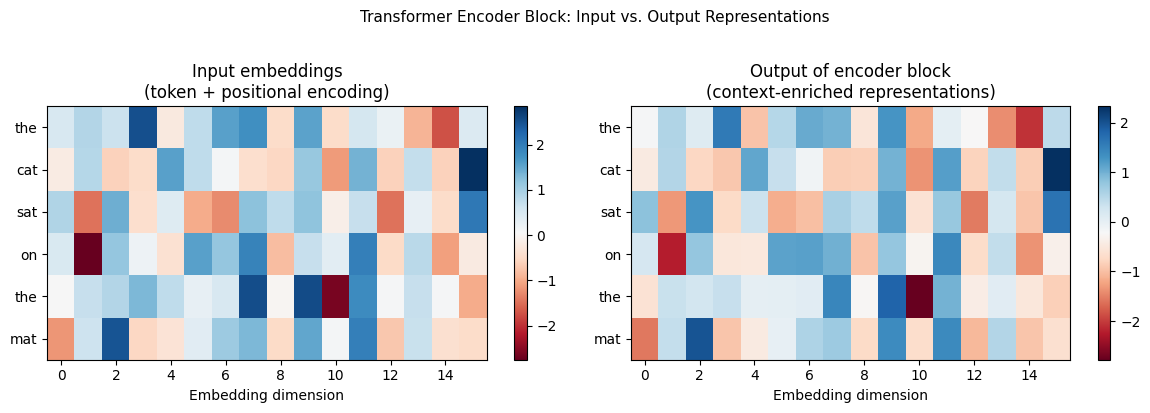

In [10]:
# ---------------------------------------------------------------
# Task D: Assemble the Full Encoder Block
#
# A single Transformer encoder block applies, in order:
#   1. Multi-head self-attention
#   2. Residual connection + Layer Norm  →  x = LayerNorm(x + MHA(x))
#   3. Feed-forward network
#   4. Residual connection + Layer Norm  →  x = LayerNorm(x + FFN(x))
# ---------------------------------------------------------------

def encoder_block(X, W_Qs, W_Ks, W_Vs, W_O, W1, b1, W2, b2):
    """
    One Transformer encoder block.

    Returns:
        out      : (T, d_model) — output of the block
        all_heads: list of H attention weight matrices, for visualisation
    """
    # --- Sub-layer 1: Multi-Head Attention + Add & Norm ---
    mha_out, all_heads = multi_head_attention(X, W_Qs, W_Ks, W_Vs, W_O)

    ## FILL IN: add residual connection then apply layer_norm
    ## x1 = LayerNorm(X + mha_out)
    x1 = layer_norm(X + mha_out)

    # --- Sub-layer 2: Feed-Forward + Add & Norm ---
    ffn_out = feed_forward(x1, W1, b1, W2, b2)

    ## FILL IN: add residual connection then apply layer_norm
    ## out = LayerNorm(x1 + ffn_out)
    out = layer_norm(x1 + ffn_out)

    return out, all_heads


block_out, all_heads = encoder_block(
    X_with_pos, W_Qs, W_Ks, W_Vs, W_O, W1, b1, W2, b2
)

print(f"Input  shape : {X_with_pos.shape}")
print(f"Output shape : {block_out.shape}")
print(f"Shapes match : {X_with_pos.shape == block_out.shape}")

# Visualise input vs output representations as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (data, title) in zip(axes, [
        (X_with_pos, 'Input embeddings\n(token + positional encoding)'),
        (block_out,  'Output of encoder block\n(context-enriched representations)')]):
    im = ax.imshow(data, cmap='RdBu', aspect='auto')
    ax.set_yticks(range(T))
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel('Embedding dimension')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('Transformer Encoder Block: Input vs. Output Representations', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

1. The sinusoidal formula uses exponentially increasing wavelengths: lower dimensions change more rapidly, while higher dimensions vary more slowly across positions.
2. In a trained model, different heads often specialise in different relationships such as local adjacency, syntactic links, coreference, or long-range dependency tracking.
3. If the two instances of "the" get different attention patterns, it shows that attention is context-sensitive: the same word can be represented differently depending on where it appears and what surrounds it.
4. Shape preservation is required so the output of one encoder block can be fed directly into the next block without changing sequence length or embedding size.
5. The output is a contextualised representation: each token now blends information from the tokens it attends to, which is the main purpose of the encoder block.
